# 02 — Exploratory Data Analysis (EDAPipeline Orchestration)

**Giai đoạn 3**: Thực hiện phân tích khám phá dữ liệu toàn diện thông qua một lệnh điều phối duy nhất `EDAPipeline.run()`.

### Mục tiêu:
1. Chạy 5 bộ phân tích theo đúng thứ tự phụ thuộc dữ liệu:
   - **DistributionAnalyzer**: Phân phối lượng mưa, kiểm định tính gián đoạn (Syntetos-Boylan ADI & CV²).
   - **CorrelationAnalyzer**: Tương quan và phát hiện đa cộng tuyến (VIF).
   - **TemporalStructureAnalyzer**: Phân tích phổ FFT và phân rã chu kỳ MSTL.
   - **StationarityAutocorrelationAnalyzer**: Kiểm định tính dừng kết hợp kết quả MSTL từ bước temporal.
   - **ExtremeEventsAnalyzer**: Phân tích ngưỡng mưa cực đoan và chu kỳ lặp lại.
2. Xác thực ngưỡng quyết định mưa / không mưa thực nghiệm (0.1 mm vs 0.6 mm).
3. Xuất kết quả có cấu trúc `EDAReport` ra file `data/processed/eda_report.json` để các mô hình tiêu thụ tự động.


In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np

from src.data.loader import DataLoader, time_series_split
from src.eda.pipeline import EDAPipeline, EDAReport


## 1. Nạp Dữ liệu & Tập Train Phân tích

Tuân thủ quy tắc `data-leakage-prevention.md`: Phân tích thống kê định hướng mô hình hóa phải được chạy trên tập Train.


In [2]:
df = DataLoader().load_data()
train_df, test_df = time_series_split(df)
print(f"Phân tích EDA trên tập Train: {len(train_df):,} ngày ({train_df['Ngày'].min().date()} → {train_df['Ngày'].max().date()})")


Phân tích EDA trên tập Train: 7,426 ngày (2000-01-01 → 2020-04-30)


## 2. Thực thi EDAPipeline

Khởi tạo và thực thi `EDAPipeline`. Pipeline tự động điều phối thứ tự truyền kết quả giữa các phân tích viên.


🔬 EDAPipeline: running all 5 analyzers in dependency order

📊 [1/5] DistributionAnalyzer
📊 DISTRIBUTION ANALYSIS INITIALIZED
   - Total Features: 30
   - Analysis Features: 30
   - Target Variable: Lượng mưa
   - Sample Size: 7,426

📈 1. DESCRIPTIVE STATISTICS SUMMARY
📊 Comprehensive Descriptive Statistics:

🔢 Basic Statistics:
                    Feature  Count     Mean   Median     Mode     Std     Min      Max
    Bức xạ sóng ngắn bề mặt   7426   5.2004   5.3197   5.8164  1.0253  0.8422   7.4844
Bức xạ sóng ngắn trời quang   7426   6.6743   6.8494   7.0034  0.4838  4.8514   7.6896
          Bức xạ khuếch tán   7426   2.4359   2.3942   2.1578  0.5678  0.5016   5.5416
      Bức xạ đỉnh khí quyển   7426   9.8211  10.2401  10.3817  0.6816  8.4977  10.5264
      Bức xạ quang hợp tổng   7426   2.4587   2.5124   2.7984  0.4668  0.2976   3.4920
                Nhiệt độ 2m   7426  27.4514  26.9700  26.3800  1.9369 19.8900  33.6600
              Điểm sương 2m   7426  22.3755  23.4000  24.1200

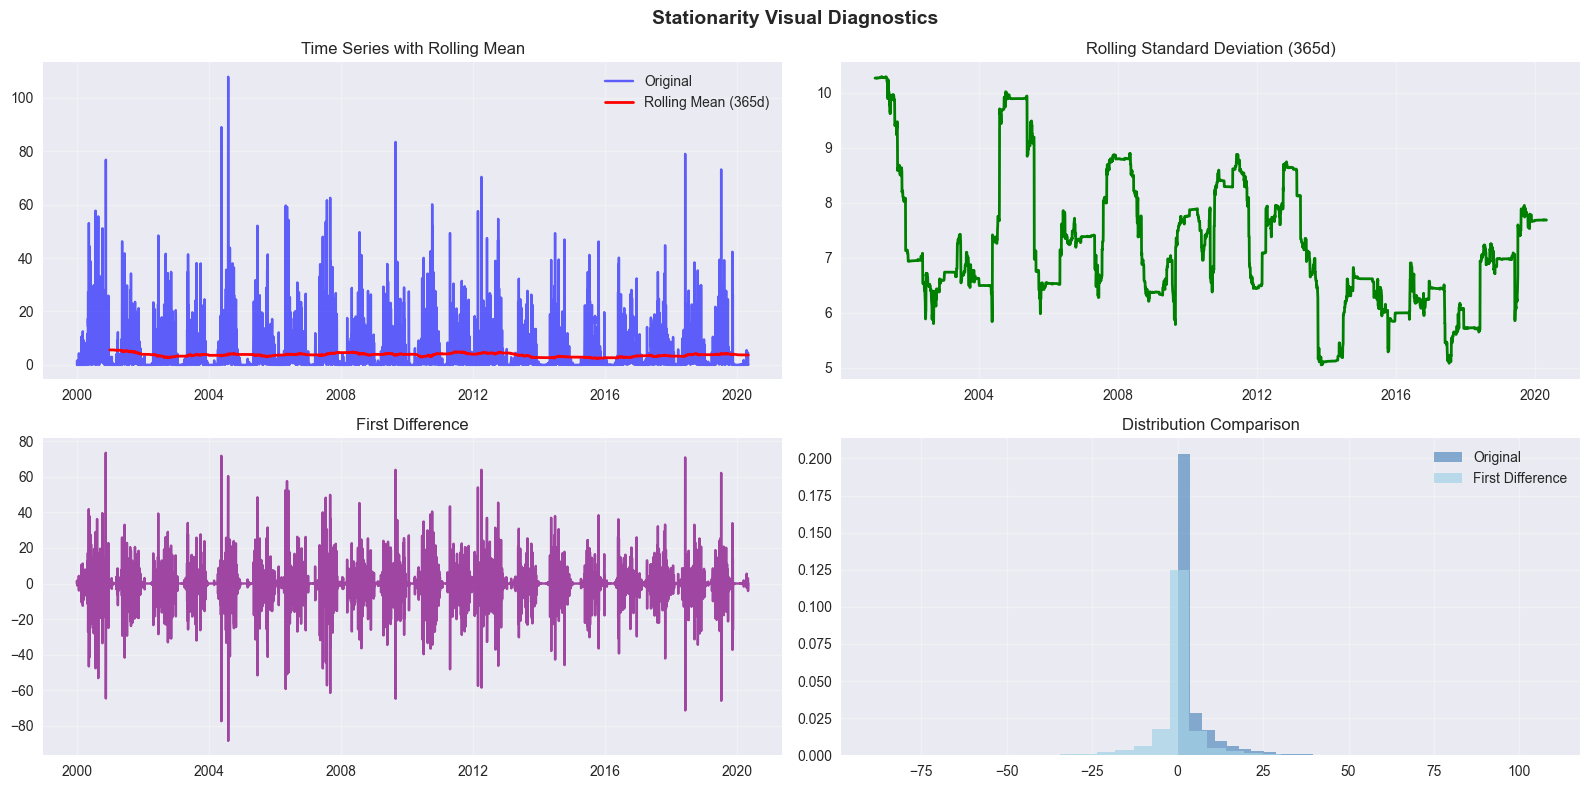


🔄 BƯỚC 2: PHÂN TÍCH TỰ TƯƠNG QUAN (THEORY-DRIVEN)
   🎯 Theory-driven max_lags: 200
      Source: theory_driven
      Based on max period: 365 + buffer: 91
   📈 ACF (Original Series):
      • Total significant lags: 160
      • Lags near representative periods: 33
   📈 PACF (Original Series):
      • Total significant lags: 40
      • Lags near representative periods: 15
   🎯 SARIMA Parameter Selection:
      • ACF lags (p): [1, 2, 3, 4, 5]
      • PACF lags (q): [1, 2, 3, 4, 5]
      • Representative periods: [7, 30, 122, 365]
      • Feasible seasonal s: 30 (cap=52)
      ⚠️ Long periods [122, 365] → use Fourier terms, not literal SARIMAX
   📊 SARIMA Suggestions: ['SARIMA(3,1,3)x(1,1,1,30)', 'SARIMA(3,0,3)x(1,0,1,30)', 'SARIMA(3,1,3)x(1,1,1,7)']


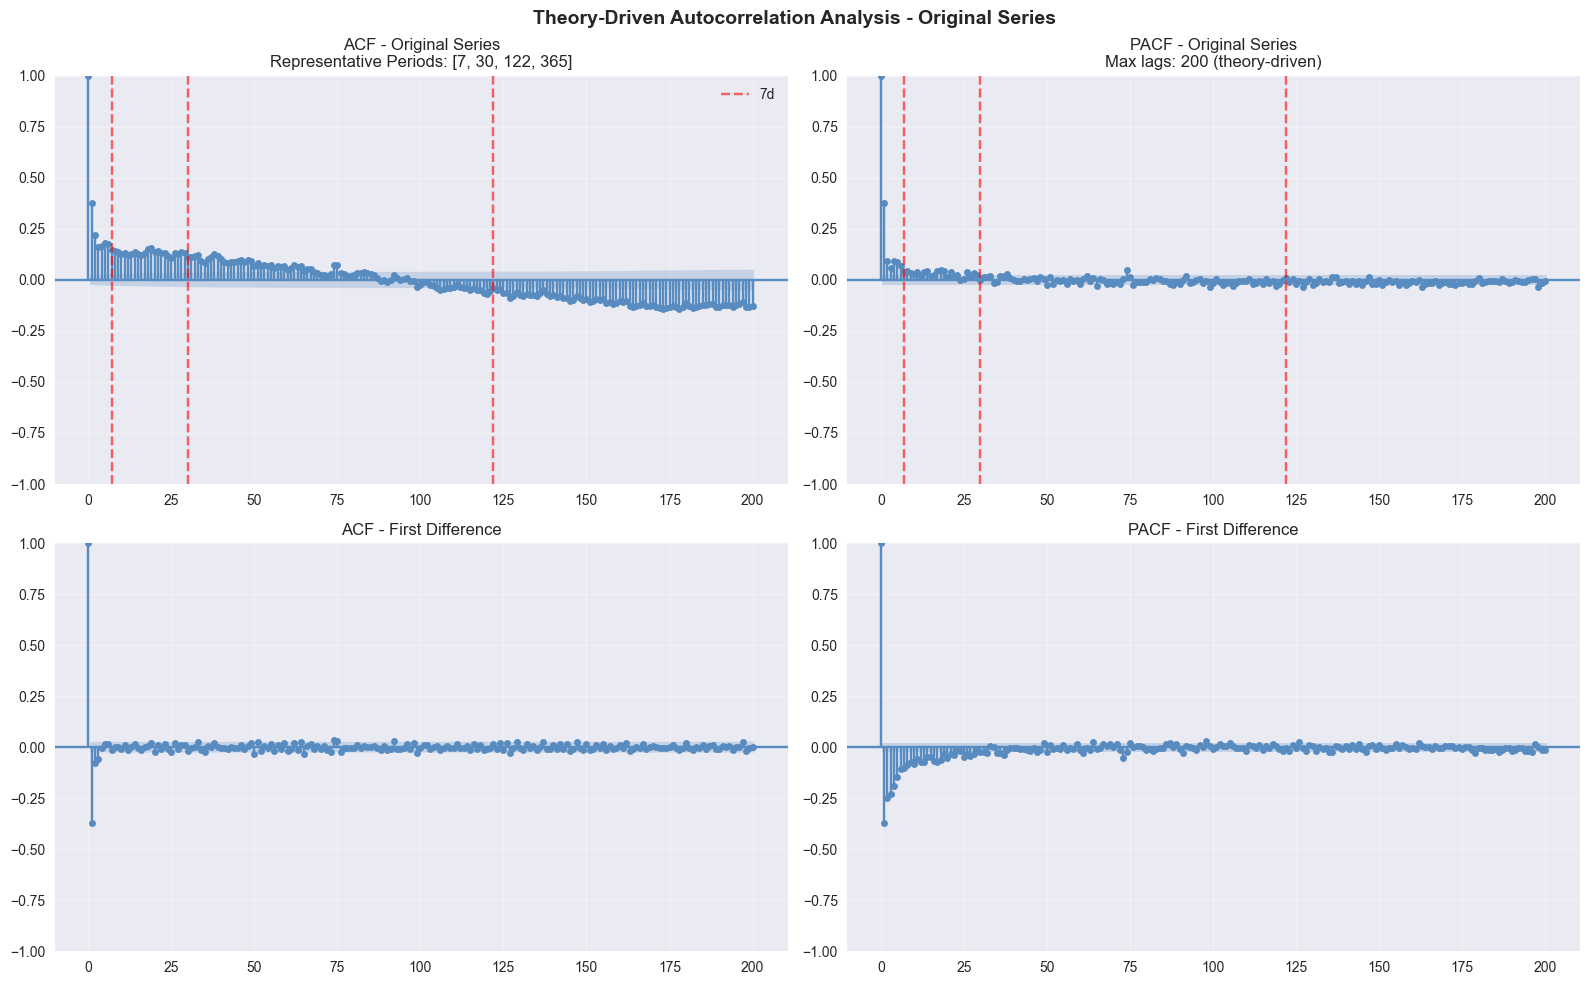


📋 BƯỚC 4: TỔNG HỢP & KẾT LUẬN (THEORY-DRIVEN)
   📊 PHÁT HIỆN CHÍNH:
      🔹 Tính dừng: Stationary
      🔹 Cần sai phân: Không
      🔹 Methodology: theory_driven
      🔹 Lags quan trọng (top 5): [1, 2, 3, 4, 5]
      🔹 Theory-validated lags: 33
      🔹 Max lags used: 200 (theory_driven)
      🎯 Representative periods: [7, 30, 122, 365]

   💡 THEORY-DRIVEN MODEL RECOMMENDATIONS:
      • ARMA models suitable
      • SARIMA models for theory-driven seasonal patterns
      • Representative periods: [7, 30, 122, 365]
      • All seasonal periods: [7, 30, 122, 365]
      • Theory-driven analysis: 33 lags validated against representative periods

📊 [5/5] ExtremeEventsAnalyzer

⛈️ COMPONENT 2: EXTREME EVENTS ANALYSIS
🔍 2.1 Extreme Events Definition
--------------------------------------------------
   📊 Extreme Event Thresholds:
      - 95th percentile: 17.73mm
      - 99th percentile: 34.76mm
      - 99.9th percentile: 62.19mm

   📈 Extreme Event Counts:
      - > 95th percentile: 372 events 

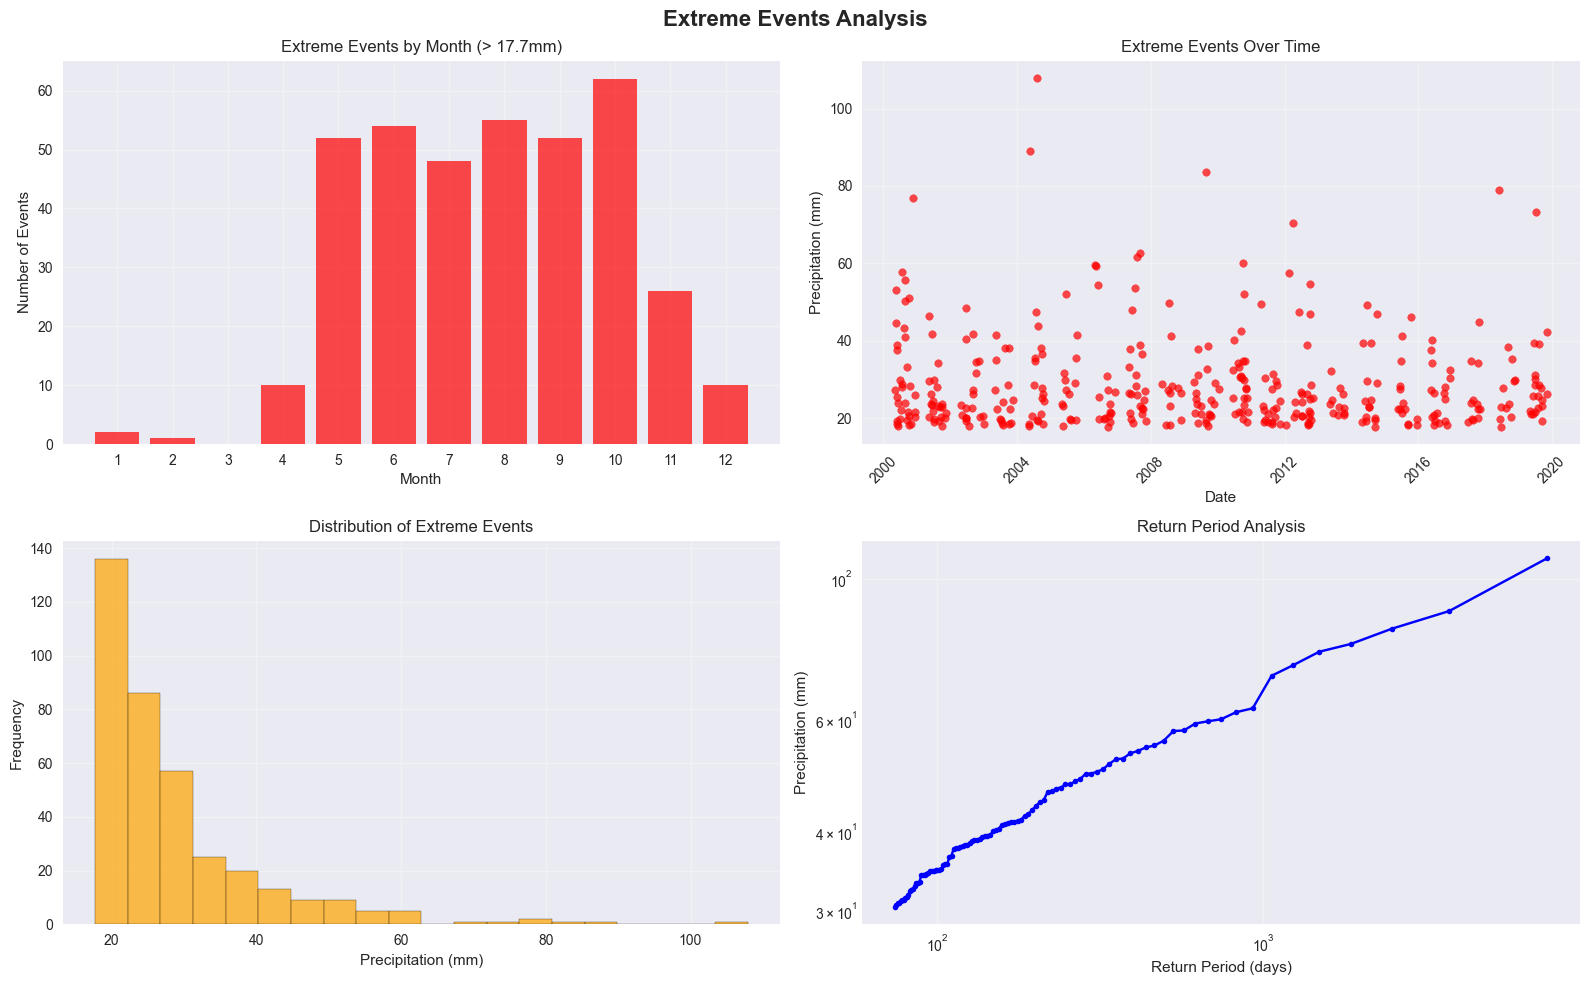

   📅 Peak extreme events month: 10

✅ EXTREME EVENTS ANALYSIS COMPLETED
   🌧️ Rain threshold validation:
      Exactly 0 mm: 26.5%
      < 0.1 mm:     38.4%
      < 0.6 mm:     50.8%
      < 1.0 mm:     55.9%
      ➤ Validated threshold: 0.1 mm (0.1mm used as default — no strong bimodal gap detected. Consider domain expert review.)

✅ EDAPipeline complete — EDAReport ready
   SARIMA order: (3, 0, 3)
   Seasonal order: (1, 1, 1, 7)
   Rain threshold: 0.1 mm (0.1mm used as default — no strong bimodal gap detected. Consider domain expert review.)
   VIF-filtered features: 3
   Wet season months: [5, 6, 7, 8, 9, 10, 11]
   Intermittency: LUMPY (ADI=1.64, CV²=2.02)


In [3]:
pipeline = EDAPipeline(train_df, target_col="Lượng mưa", date_col="Ngày")
report = pipeline.run()

## 3. Tổng hợp Kết luận Thống kê Chính

Xem các tham số cấu trúc trích xuất được trong `EDAReport`:


In [4]:
print("=" * 60)
print("📋 TỔNG HỢP CÁC KẾT LUẬN TỪ EDAPIPELINE")
print("=" * 60)
print(f"1. Ngưỡng mưa xác thực:       {report.validated_rain_threshold} mm")
print(f"   Lý do:                     {report.rain_threshold_justification}")
print(f"2. Phân loại gián đoạn:       {report.intermittency_classification}")
print(f"   Chỉ số ADI:                {report.intermittency_adi:.2f} (Ngưỡng: 1.32)")
print(f"   Hệ số biến thiên CV²:      {report.intermittency_cv2:.2f} (Ngưỡng: 0.49)")
print(f"   Khuyến nghị kiến trúc:     {report.intermittency_model_rec}")
print(f"3. Gợi ý bậc mô hình SARIMA:  {report.suggested_sarima_order}")
print(f"   Bậc chu kỳ thời vụ:        {report.suggested_seasonal_order}")
print(f"4. Các tháng mùa mưa:         {report.wet_season_months}")
print(f"5. Chu kỳ đại diện phát hiện: {report.representative_periods} ngày")
print("=" * 60)


📋 TỔNG HỢP CÁC KẾT LUẬN TỪ EDAPIPELINE
1. Ngưỡng mưa xác thực:       0.1 mm
   Lý do:                     0.1mm used as default — no strong bimodal gap detected. Consider domain expert review.
2. Phân loại gián đoạn:       LUMPY
   Chỉ số ADI:                1.64 (Ngưỡng: 1.32)
   Hệ số biến thiên CV²:      2.02 (Ngưỡng: 0.49)
   Khuyến nghị kiến trúc:     TSB or IMAPA recommended; specialized intermittent-demand models or Tweedie-loss single-stage regression are recommended (two-stage is a legacy alternative but prone to recursive error propagation)
3. Gợi ý bậc mô hình SARIMA:  (3, 0, 3)
   Bậc chu kỳ thời vụ:        (1, 1, 1, 7)
4. Các tháng mùa mưa:         [5, 6, 7, 8, 9, 10, 11]
5. Chu kỳ đại diện phát hiện: [7, 30, 122, 365] ngày


## 4. Lưu trữ Kết quả (Serialization sang data/processed/eda_report.json)

Lưu `EDAReport` ra file JSON theo cơ chế truyền dữ liệu giữa các notebook đã thiết kế tại Bước 4.


In [5]:
report_path = ROOT_DIR / "data" / "processed" / "eda_report.json"
report.to_json(report_path)
print(f"✅ Đã lưu EDAReport tại: {report_path}")

# Kiểm tra load lại
loaded_report = EDAReport.from_json(report_path)
assert loaded_report.suggested_sarima_order == report.suggested_sarima_order
assert loaded_report.validated_rain_threshold == report.validated_rain_threshold
print("✅ Tái nạp báo cáo từ JSON thành công và khớp chính xác 100%!")


✅ Đã lưu EDAReport tại: d:\DS108_project\data\processed\eda_report.json
✅ Tái nạp báo cáo từ JSON thành công và khớp chính xác 100%!


## 5. Tổng kết Gate Check (Stage 3)

| Tiêu chuẩn kiểm tra | Kết quả | Ý nghĩa thực tiễn |
|---|---|---|
| Phân loại Syntetos-Boylan | **LUMPY** | Căn cứ toán học lựa chọn mô hình intermittent-demand chuyên biệt (Croston/TSB/IMAPA) hoặc Tweedie loss |
| Ngưỡng mưa thực nghiệm | **0.1 mm** | Tách biệt chuẩn xác giữa ngày khô ráo và ngày có mưa |
| Phân rã mùa vụ | 5–11 | Mùa mưa Tây Nam rõ rệt từ tháng 5 đến tháng 11 |
| Serialization | **JSON OK** | Truyền tham số lập trình an toàn sang Stage 4 |
